### Link: https://pennylane.ai/qml/demos/tutorial_variational_classifier

In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

In [2]:
# dev = qml.device("default.qubit")

In [3]:
import pennylane as qml
#import numpy as np
import matplotlib.pyplot as plt


from pennylane_calculquebec.API.client import MonarqClient
from pennylane_calculquebec.API.adapter import ApiAdapter


client = MonarqClient("https://manager.anyonlabs.com", "your_user", "your_token")
ApiAdapter.initialize(client)


from pennylane_calculquebec.processing.config import MonarqDefaultConfig, NoPlaceNoRouteConfig, ProcessingConfig, PrintDefaultConfig, PrintNoPlaceNoRouteConfig
from pennylane_calculquebec.processing.steps import IBUReadoutMitigation, MatrixReadoutMitigation, PrintResults

    
my_config = PrintDefaultConfig("yukon") # default configuration: transpilation steps (placement and routing, gate decomposition and circuit optimization)
my_config_no_routing = PrintNoPlaceNoRouteConfig(False)


/media/PhD/miniconda3/envs/pennylane_gpu/lib/python3.11/site-packages/pennylane_calculquebec/base_device.py:10: PennyLaneDeprecationWarning: `pennylane.devices.DefaultExecutionConfig` is deprecated and will be removed in v0.44. Please use `ExecutionConfig()` instead.
  from pennylane.devices import DefaultExecutionConfig, ExecutionConfig


In [4]:
benchmark = ApiAdapter.get_qubits_and_couplers("yukon")
raw_qubits = benchmark["qubits"]
sorted_qubits = dict(sorted(raw_qubits.items(), key=lambda item: int(item[0])))

data = []

print("Qubit metrics:")
for qubit, info in sorted_qubits.items():
    qubit_data = [
        info['readoutState0Fidelity'],
        info['readoutState1Fidelity'],
        info['singleQubitGateFidelity'],
        info['t1'],
        info['t2Echo'],
        info['t2Ramsey']
    ]
    data.append(qubit_data)
    print(f"Qubit {qubit}: {qubit_data}")

coupler = benchmark["couplers"]
print("\nCoupler metrics:")
print(coupler)

Qubit metrics:
Qubit 0: [0.98, 0.93, 0.9985440611714567, 9.124000000000006e-06, 3.5675941705383803e-06, 1.6683550355305486e-06]
Qubit 1: [0.976, 0.868, 0.9972837241589421, 7.510701542833738e-06, 4.019927057801977e-06, 8.761675642752606e-07]
Qubit 2: [0.986, 0.84, 0.9955420276836314, 6.474267881883525e-06, 1.8409950885024295e-06, 7.024501121676383e-07]
Qubit 3: [0.986, 0.895, 0.9967890077803654, 6.789133736980253e-06, 5.368206582550032e-06, 1.7016655111220927e-06]
Qubit 4: [0.987, 0.889, 0.9937175907730281, 5.119177506073873e-06, 7.723692669493234e-06, 2.2939803809573805e-06]
Qubit 5: [0.975, 0.922, 0.9973905264652131, 1.0225200000000007e-05, 6.793472212517064e-06, 1.6540008672209833e-06]

Coupler metrics:
{'0': {'czGateFidelity': 0.9370053665151792}, '1': {'czGateFidelity': 0.9710122979803586}, '2': {'czGateFidelity': 0.9821757064232651}, '3': {'czGateFidelity': 0.928188495414762}, '4': {'czGateFidelity': 0.9527715422832329}}


In [5]:
dev = qml.device("monarq.backup", client = client, wires = 4, shots = 1000,  processing_config = my_config)
dev.project_name = 'samar'#"17ebfcd6-59de-4140-8af8-5c265326a8"
dev.circuit_name = 'samar_circuit'#"ghz"

In [6]:
def layer(layer_weights):
    for wire in range(4):
        qml.Rot(*layer_weights[wire], wires=wire)

    for wires in ([0, 1], [1, 2], [2, 3], [3, 0]):
        qml.CNOT(wires)

In [7]:
def state_preparation(x):
    qml.BasisState(x, wires=[0, 1, 2, 3])

In [8]:
@qml.qnode(dev)
def circuit(weights, x):
    state_preparation(x)

    for layer_weights in weights:
        layer(layer_weights)

    return qml.expval(qml.PauliZ(0))

In [9]:
def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

In [10]:
def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)

In [11]:
def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

In [12]:
def cost(weights, bias, X, Y):
    predictions = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

In [13]:
data = np.loadtxt("variational_classifier/data/parity_train.txt", dtype=int)
X = np.array(data[:, :-1])
Y = np.array(data[:, -1])
Y = Y * 2 - 1  # shift label from {0, 1} to {-1, 1}

for x,y in zip(X, Y):
    print(f"x = {x}, y = {y}")

x = [0 0 0 1], y = 1
x = [0 0 1 0], y = 1
x = [0 1 0 0], y = 1
x = [0 1 0 1], y = -1
x = [0 1 1 0], y = -1
x = [0 1 1 1], y = 1
x = [1 0 0 0], y = 1
x = [1 0 0 1], y = -1
x = [1 0 1 1], y = 1
x = [1 1 1 1], y = -1


In [14]:
np.random.seed(0)
num_qubits = 4
num_layers = 2
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

print("Weights:", weights_init)
print("Bias: ", bias_init)

Weights: [[[ 0.01764052  0.00400157  0.00978738]
  [ 0.02240893  0.01867558 -0.00977278]
  [ 0.00950088 -0.00151357 -0.00103219]
  [ 0.00410599  0.00144044  0.01454274]]

 [[ 0.00761038  0.00121675  0.00443863]
  [ 0.00333674  0.01494079 -0.00205158]
  [ 0.00313068 -0.00854096 -0.0255299 ]
  [ 0.00653619  0.00864436 -0.00742165]]]
Bias:  0.0


In [15]:
opt = NesterovMomentumOptimizer(0.5)
batch_size = 5

In [19]:
import datetime
start_time = datetime.datetime.now()

In [20]:
track_loss = []
track_acc = []

In [21]:
weights = weights_init
bias = bias_init
for it in range(100):

    # Update the weights by one optimizer step, using only a limited batch of data
    batch_index = np.random.randint(0, len(X), (batch_size,))
    X_batch = X[batch_index]
    Y_batch = Y[batch_index]
    weights, bias = opt.step(cost, weights, bias, X=X_batch, Y=Y_batch)

    # Compute accuracy
    predictions = [np.sign(variational_classifier(weights, bias, x)) for x in X]

    current_cost = cost(weights, bias, X, Y)
    acc = accuracy(Y, predictions)
    track_loss.append(current_cost)
    track_acc.append(acc)

    print(f"Iter: {it+1:4d} | Cost: {current_cost:0.7f} | Accuracy: {acc:0.7f}")

end_time = datetime.datetime.now()

2 0 1 3
3 1 2 0
1 2 0 3
2 3 1 0
0 1 2 3
1 2 3 0
0 2 3 1
1 3 0 2
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
2 0 1 3
3 1 2 0
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1
1 3 0 2
0 2 3 1


KeyboardInterrupt: 

In [24]:
print(start_time)

2025-09-07 22:45:00.610115


In [29]:
len(track_loss)

34

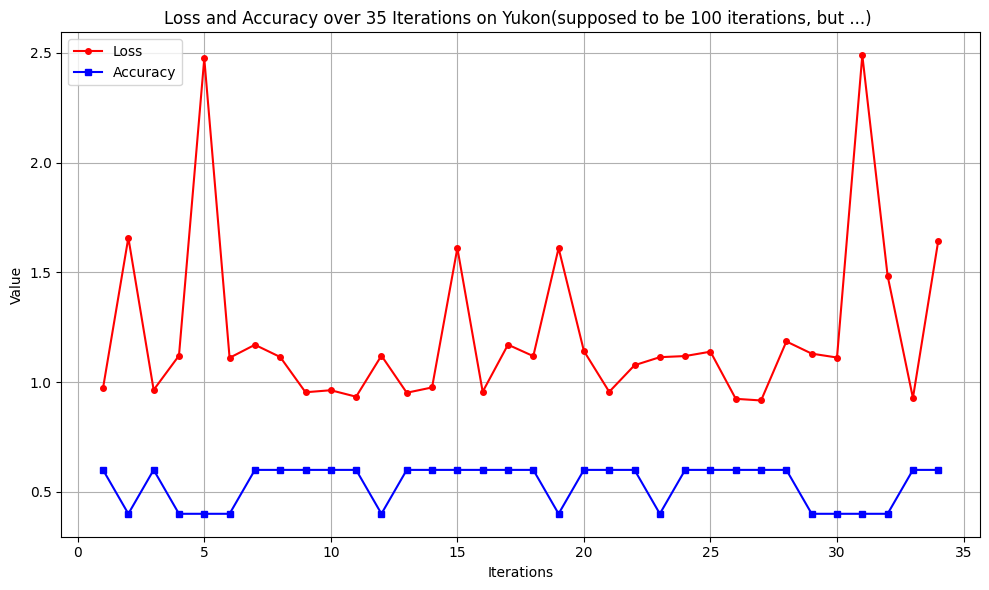

In [32]:
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
iters = list(range(1, len(track_loss)+1))  # 100 iterations

# Create the plot
plt.figure(figsize=(10, 6))

# Plot loss
plt.plot(iters, track_loss, label='Loss', color='red', marker='o', markersize=4, linestyle='-')

# Plot accuracy
plt.plot(iters, track_acc, label='Accuracy', color='blue', marker='s', markersize=4, linestyle='-')

# Add labels and title
plt.xlabel('Iterations')
plt.ylabel('Value')
plt.title('Loss and Accuracy over 35 Iterations on Yukon(supposed to be 100 iterations, but ...) ')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [33]:
data = np.loadtxt("variational_classifier/data/parity_test.txt", dtype=int)
X_test = np.array(data[:, :-1])
Y_test = np.array(data[:, -1])
Y_test = Y_test * 2 - 1  # shift label from {0, 1} to {-1, 1}

predictions_test = [np.sign(variational_classifier(weights, bias, x)) for x in X_test]

for x,y,p in zip(X_test, Y_test, predictions_test):
    print(f"x = {x}, y = {y}, pred={p}")

acc_test = accuracy(Y_test, predictions_test)
print("Accuracy on unseen data:", acc_test)

0 1 2 3
1 2 3 0
2 3 0 1
3 0 1 2
0 2 1 3
1 3 2 0
0 1 2 3
1 2 3 0
0 1 2 3
1 2 3 0
0 1 3 2
1 2 0 3
x = [0 0 0 0], y = -1, pred=1.0
x = [0 0 1 1], y = -1, pred=1.0
x = [1 0 1 0], y = -1, pred=1.0
x = [1 1 1 0], y = 1, pred=1.0
x = [1 1 0 0], y = -1, pred=1.0
x = [1 1 0 1], y = 1, pred=1.0
Accuracy on unseen data: 0.3333333333333333
